# Laboratory Exercise: Image Classification Using Pre-trained Models

**Course:** Data Science  
**Activity:** Model Inference on Custom Dataset

## Objective

This laboratory applies transfer learning with pre-trained convolutional neural network (CNN) models to a custom image classification dataset. Five models from `torchvision.models` are compared using accuracy, precision, recall, and F1-score.

The custom dataset contains five classes:

- birds
- cars
- cats
- flowers
- monkeys

The experiment uses an 80/20 stratified train-test split, with 20 images for training and 5 images for testing.


## 1. Import Libraries

The notebook uses PyTorch and Torchvision for deep learning, Pandas and Matplotlib for analysis and visualization, and Scikit-learn for dataset splitting and evaluation metrics.

> If the required packages are already installed in the environment, there is no need to run a separate installation command.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torchvision import datasets, models
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)


PyTorch version: 2.14.0+cpu
Torchvision version: 0.29.0+cpu


## 2. Set the Device and Random Seed

The device is selected automatically. CUDA is used when an NVIDIA GPU is available; otherwise, the notebook uses the CPU.

A fixed random seed is used to make the train-test split and model initialization more reproducible.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cpu


## 3. Load and Prepare the Custom Dataset

The images are resized to `224 × 224`, converted to tensors, and normalized using the standard ImageNet mean and standard deviation expected by the pre-trained models.

**Dataset path:** Change `DATASET_PATH` if the images are stored in a different folder.


In [3]:
# Change this path if your dataset is stored somewhere else.
DATASET_PATH = r"D:\data\dataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(dataset))


Classes: ['birds', 'cars', 'cats', 'flowers', 'monkeys']
Number of classes: 5
Total images: 25


In [4]:
print("Class mapping:")
print(dataset.class_to_idx)


Class mapping:
{'birds': 0, 'cars': 1, 'cats': 2, 'flowers': 3, 'monkeys': 4}


In [5]:
from collections import Counter

class_counts = Counter(dataset.targets)

print("Images per class:")
for class_name, class_index in dataset.class_to_idx.items():
    print(f"{class_name}: {class_counts[class_index]} images")


Images per class:
birds: 5 images
cars: 5 images
cats: 5 images
flowers: 5 images
monkeys: 5 images


## 4. Visualize Sample Images

The following cell displays a few images from the custom dataset. The ImageNet normalization is temporarily reversed so the images can be displayed correctly.


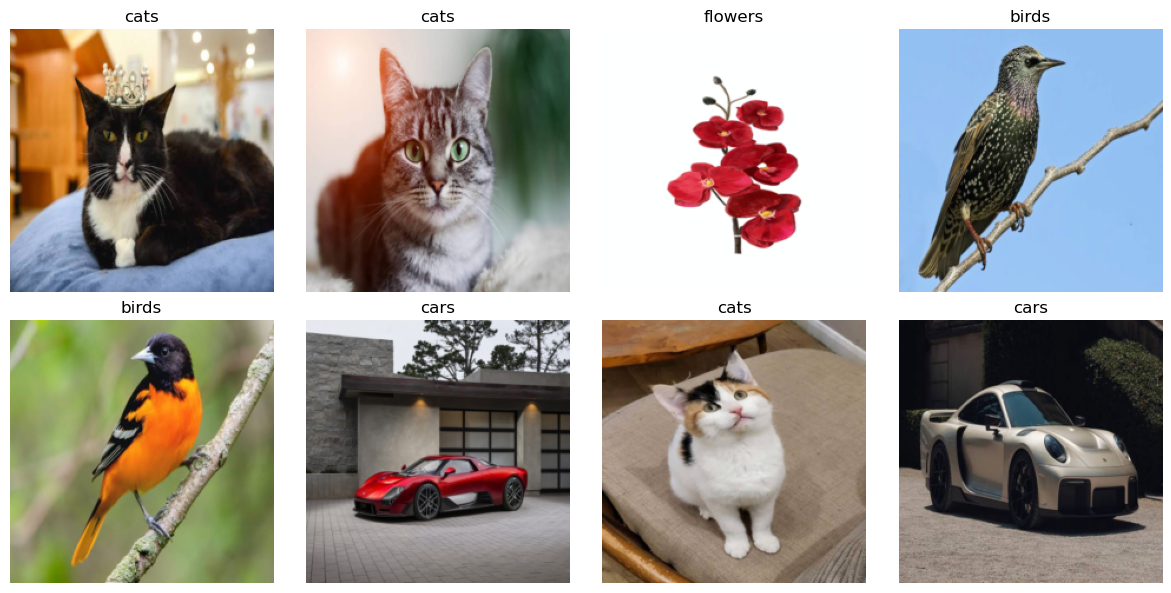

In [6]:
def show_images(dataset, num_images=8):
    num_images = min(num_images, len(dataset))

    loader = DataLoader(
        dataset,
        batch_size=num_images,
        shuffle=True
    )

    images, labels = next(iter(loader))

    cols = 4
    rows = int(np.ceil(num_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(num_images):
        image = images[i].numpy().transpose((1, 2, 0))
        image = std * image + mean
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].set_title(class_names[labels[i].item()])
        axes[i].axis("off")

    for i in range(num_images, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_images(dataset)


## 5. Create a Stratified Train-Test Split

Because the dataset contains only 25 images, a stratified split is used so that every class is represented in both the training and testing sets.

- Training set: 20 images
- Testing set: 5 images
- Test proportion: 20%


In [7]:
targets = np.array(dataset.targets)
indices = np.arange(len(dataset))

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=targets
)

train_dataset = Subset(dataset, train_indices)
test_dataset = Subset(dataset, test_indices)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))


Training images: 20
Testing images: 5


In [8]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))


Training batches: 5
Testing batches: 2


## 6. Define the Five Pre-trained Models

The ImageNet-trained feature extraction layers are frozen, while the final classification layer is replaced with a new layer containing five outputs for the custom dataset.

The five models are:

1. ResNet18
2. VGG16
3. DenseNet121
4. MobileNetV3 Small
5. EfficientNet-B0


In [9]:
def create_models(num_classes):
    models_dict = {}

    # ResNet18
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    models_dict["ResNet18"] = model

    # VGG16
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    models_dict["VGG16"] = model

    # DenseNet121
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    models_dict["DenseNet121"] = model

    # MobileNetV3 Small
    model = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.DEFAULT
    )
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        num_classes
    )
    models_dict["MobileNetV3"] = model

    # EfficientNet-B0
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.DEFAULT
    )
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        num_classes
    )
    models_dict["EfficientNet-B0"] = model

    return models_dict


models_dict = create_models(num_classes)

for name, model in models_dict.items():
    model = model.to(device)
    print(name, "loaded successfully")


ResNet18 loaded successfully
VGG16 loaded successfully
DenseNet121 loaded successfully
MobileNetV3 loaded successfully
EfficientNet-B0 loaded successfully


### Why is `model.eval()` used during testing?

During evaluation, `model.eval()` changes the behavior of layers such as dropout and batch normalization so that the model behaves consistently during prediction. During training, `model.train()` is used instead.


## 7. Train the Classification Layers

Only the newly created classification layers are trainable. The pre-trained feature extraction layers remain frozen.

The models are trained for 10 epochs using Adam optimization and cross-entropy loss.


In [10]:
def train_model(model, train_loader, epochs=10, learning_rate=0.001):
    model = model.to(device)

    trainable_params = [
        param for param in model.parameters()
        if param.requires_grad
    ]

    optimizer = optim.Adam(
        trainable_params,
        lr=learning_rate
    )

    criterion = nn.CrossEntropyLoss()

    history = {
        "loss": [],
        "accuracy": []
    }

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total

        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_accuracy)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

    model.eval()
    return model, history


In [11]:
EPOCHS = 10

trained_models = {}
training_histories = {}

for name, model in models_dict.items():
    print("\n" + "=" * 50)
    print(f"Training: {name}")
    print("=" * 50)

    trained_model, history = train_model(
        model,
        train_loader,
        epochs=EPOCHS
    )

    trained_models[name] = trained_model
    training_histories[name] = history



Training: ResNet18
Epoch [1/10] Loss: 1.6720 Accuracy: 20.00%
Epoch [2/10] Loss: 1.2077 Accuracy: 55.00%
Epoch [3/10] Loss: 0.9921 Accuracy: 85.00%
Epoch [4/10] Loss: 0.7160 Accuracy: 100.00%
Epoch [5/10] Loss: 0.5889 Accuracy: 95.00%
Epoch [6/10] Loss: 0.4749 Accuracy: 100.00%
Epoch [7/10] Loss: 0.2915 Accuracy: 100.00%
Epoch [8/10] Loss: 0.4293 Accuracy: 95.00%
Epoch [9/10] Loss: 0.1807 Accuracy: 100.00%
Epoch [10/10] Loss: 0.1509 Accuracy: 100.00%

Training: VGG16
Epoch [1/10] Loss: 2.0629 Accuracy: 25.00%
Epoch [2/10] Loss: 0.3303 Accuracy: 100.00%
Epoch [3/10] Loss: 0.0651 Accuracy: 100.00%
Epoch [4/10] Loss: 0.0204 Accuracy: 100.00%
Epoch [5/10] Loss: 0.0165 Accuracy: 100.00%
Epoch [6/10] Loss: 0.0033 Accuracy: 100.00%
Epoch [7/10] Loss: 0.0022 Accuracy: 100.00%
Epoch [8/10] Loss: 0.0011 Accuracy: 100.00%
Epoch [9/10] Loss: 0.0028 Accuracy: 100.00%
Epoch [10/10] Loss: 0.0009 Accuracy: 100.00%

Training: DenseNet121
Epoch [1/10] Loss: 1.7669 Accuracy: 10.00%
Epoch [2/10] Loss: 1.

## 8. Evaluate the Models

The models are evaluated using:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score

Weighted averaging is used because the metrics should account for the number of samples in each class.


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(
                predictions.cpu().numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Labels": all_labels,
        "Predictions": all_predictions
    }


In [ ]:
results = {}

for name, model in trained_models.items():
    results[name] = evaluate_model(
        model,
        test_loader
    )

    print(f"\n{name}")
    print(f"Accuracy:  {results[name]['Accuracy']:.2f}")
    print(f"Precision: {results[name]['Precision']:.2f}")
    print(f"Recall:    {results[name]['Recall']:.2f}")
    print(f"F1-score:  {results[name]['F1-score']:.2f}")


## 9. Model Performance Comparison

The results are converted to percentages to make the comparison easier to read.


In [ ]:
comparison = []

for name, result in results.items():
    comparison.append({
        "Model": name,
        "Accuracy": result["Accuracy"] * 100,
        "Precision": result["Precision"] * 100,
        "Recall": result["Recall"] * 100,
        "F1-score": result["F1-score"] * 100
    })

results_df = pd.DataFrame(comparison)

results_df.round(2)


## 10. Performance Visualization


In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison of Pre-trained Models")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 110)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


## 11. Confusion Matrices

Confusion matrices show which classes were correctly classified and which classes were confused with one another.


In [ ]:
for name, result in results.items():
    cm = confusion_matrix(
        result["Labels"],
        result["Predictions"],
        labels=list(range(num_classes))
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(
        ax=ax,
        xticks_rotation=45
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()


## 12. Actual vs. Predicted Classes

The following table shows the prediction made for each test image.


In [ ]:
prediction_rows = []

for name, result in results.items():
    for actual, predicted in zip(
        result["Labels"],
        result["Predictions"]
    ):
        prediction_rows.append({
            "Model": name,
            "Actual": class_names[actual],
            "Predicted": class_names[predicted],
            "Correct": actual == predicted
        })

prediction_df = pd.DataFrame(prediction_rows)

prediction_df


## 13. Training Results

The training histories can be inspected to see how the loss and accuracy changed across epochs.


In [ ]:
training_summary = []

for name, history in training_histories.items():
    training_summary.append({
        "Model": name,
        "Final Training Accuracy (%)": history["accuracy"][-1],
        "Final Training Loss": history["loss"][-1]
    })

pd.DataFrame(training_summary).round(2)


## 14. Analysis

The five pre-trained models were evaluated on a custom image classification dataset containing birds, cars, cats, flowers, and monkeys. The dataset contained 25 images in total, with five images per class. A stratified 80/20 split resulted in 20 training images and five testing images.

All five models reached 100% training accuracy by the final epoch. On the test set, ResNet18 and DenseNet121 correctly classified all five test images, resulting in 100% accuracy, precision, recall, and F1-score. VGG16, MobileNetV3, and EfficientNet-B0 correctly classified four out of five test images, resulting in 80% accuracy and 80% recall. Their weighted precision was 70%, while their weighted F1-score was approximately 73.33%.

The only test image that was misclassified by some models was the bird image. VGG16 and EfficientNet-B0 predicted the bird image as a car, while MobileNetV3 predicted it as a monkey. The other four test images were correctly classified by all five models.

The results demonstrate that the pre-trained CNN architectures were able to adapt to the custom five-class classification task. However, the dataset was very small, so the test results should be interpreted cautiously. With only five test images, one incorrect prediction changes the accuracy by 20 percentage points. Therefore, these results provide a basic laboratory comparison rather than a reliable estimate of how the models would perform on a larger dataset.


## 15. Dataset Limitation

The main limitation of this experiment was the small dataset size. Only 25 images were available, with five images per class. As a result, only five images were used for testing. Because one image represents 20% of the test set, a single incorrect prediction has a large effect on the evaluation metrics.

A larger and more diverse dataset would provide a more reliable assessment of model performance and would make the comparison between architectures more meaningful.


## 16. Conclusion

The laboratory demonstrated the use of pre-trained deep learning models for image classification using a custom dataset. Five models from `torchvision.models` were evaluated: ResNet18, VGG16, DenseNet121, MobileNetV3, and EfficientNet-B0.

ResNet18 and DenseNet121 correctly classified all five test images, while VGG16, MobileNetV3, and EfficientNet-B0 correctly classified four out of five. The main classification error involved the bird image, which was predicted as either cars or monkeys by the models that made an error.

The activity showed how different CNN architectures can produce different results even when they are applied to the same dataset. It also demonstrated the importance of using appropriate evaluation metrics and considering dataset size when interpreting model performance. A larger dataset with more images per class would be useful for a more reliable comparison in future experiments.
